Dataset 'employee_performance.csv' generated successfully with 4000 records.

--- STEP 1: Central Tendency & Dispersion ---
Salary - Mean: $69,941.07 | Median: $69,979.00 | Mode: $62,248
Projects Completed - Variance: 4.92 | Std Dev: 2.22

--- STEP 2: Probability & Events ---
Overall Probability of Promotion: 21.50%

Contingency Table (Promotion vs Department):
Department        Finance   HR   IT  Marketing  Sales
Promotion_Status                                     
No                    614  596  656        651    623
Yes                   203  172  173        158    154

Conditional Probability P(Promotion | Score > 80): 48.13%

--- STEP 3: Distributions & Visualization ---


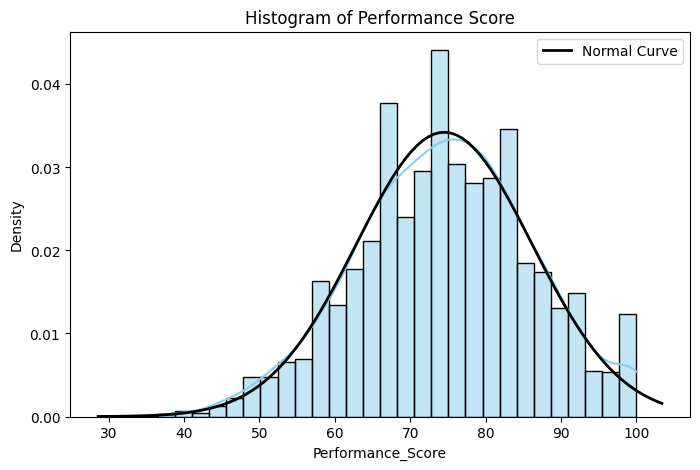

Salary Skewness: 0.0019 (Values near 0 indicate symmetry)
Salary Kurtosis: -0.0256 (Values > 0 indicate heavier tails)



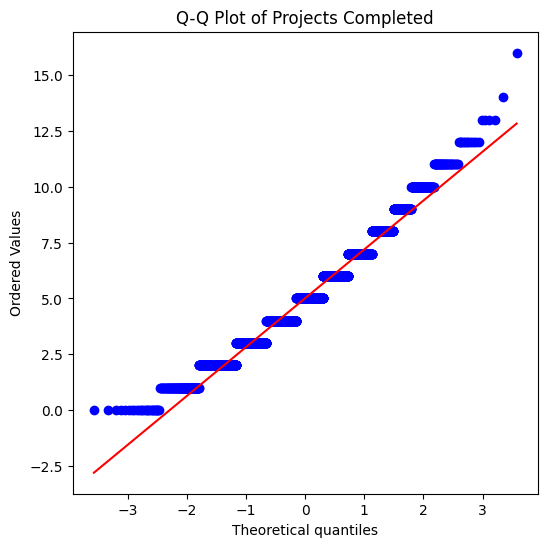

--- STEP 4: Linear Algebra Application ---
Employee 1 Vector: [ 3.         40.69815814]
Employee 2 Vector: [ 7.         40.50863657]
Dot Product (Emp 1 & 2): 1669.63
Employee 1 - L1 Norm (Norm 1): 43.70
Employee 1 - L2 Norm (Norm 2): 40.81
Angle between Emp 1 and Emp 2 vectors: 5.59 degrees


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ==========================================
# STEP 0: Generate Synthetic Dataset
# ==========================================
np.random.seed(42)
n_employees = 4000

data = {
    'Employee_ID': range(1001, 1001 + n_employees),
    'Department': np.random.choice(['IT', 'HR', 'Sales', 'Finance', 'Marketing'], n_employees),
    'Age': np.random.randint(22, 60, n_employees),
    'Salary': np.random.normal(70000, 15000, n_employees).astype(int), # Normally distributed
    'Projects_Completed': np.random.poisson(5, n_employees),           # Poisson distributed
    'Working_Hours': np.random.normal(40, 5, n_employees),
    'Performance_Score': np.clip(np.random.normal(75, 12, n_employees), 0, 100).astype(int)
}

# Create a logical promotion rule with some randomness
df = pd.DataFrame(data)
promotion_chance = (df['Performance_Score'] > 80) & (df['Projects_Completed'] >= 5)
df['Promotion_Status'] = np.where(promotion_chance,
                                  np.random.choice(['Yes', 'No'], n_employees, p=[0.8, 0.2]),
                                  np.random.choice(['Yes', 'No'], n_employees, p=[0.1, 0.9]))

df.to_csv("employee_performance.csv", index=False)
print("Dataset 'employee_performance.csv' generated successfully with 4000 records.\n")

# ==========================================
# STEP 1: Central Tendency & Dispersion
# ==========================================
print("--- STEP 1: Central Tendency & Dispersion ---")
salary_mean = df['Salary'].mean()
salary_median = df['Salary'].median()
salary_mode = df['Salary'].mode()[0]

projects_var = df['Projects_Completed'].var()
projects_std = df['Projects_Completed'].std()

print(f"Salary - Mean: ${salary_mean:,.2f} | Median: ${salary_median:,.2f} | Mode: ${salary_mode:,}")
print(f"Projects Completed - Variance: {projects_var:.2f} | Std Dev: {projects_std:.2f}\n")


# ==========================================
# STEP 2: Probability & Events
# ==========================================
print("--- STEP 2: Probability & Events ---")
prob_promoted = (df['Promotion_Status'] == 'Yes').mean()
print(f"Overall Probability of Promotion: {prob_promoted:.2%}")

contingency_table = pd.crosstab(df['Promotion_Status'], df['Department'])
print("\nContingency Table (Promotion vs Department):")
print(contingency_table)

# Conditional Probability: P(Promotion | Performance > 80)
high_performers = df[df['Performance_Score'] > 80]
prob_promo_given_high_perf = (high_performers['Promotion_Status'] == 'Yes').mean()
print(f"\nConditional Probability P(Promotion | Score > 80): {prob_promo_given_high_perf:.2%}\n")


# ==========================================
# STEP 3: Distributions & Visualization
# ==========================================
print("--- STEP 3: Distributions & Visualization ---")
# 1. Histogram with Gaussian curve
plt.figure(figsize=(8,5))
sns.histplot(df['Performance_Score'], kde=True, bins=30, color='skyblue', stat="density")
# Overlay theoretical Gaussian
mu, std = df['Performance_Score'].mean(), df['Performance_Score'].std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label='Normal Curve')
plt.title('Histogram of Performance Score')
plt.legend()
plt.show()

# 2. Skewness and Kurtosis
sal_skew = df['Salary'].skew()
sal_kurt = df['Salary'].kurtosis()
print(f"Salary Skewness: {sal_skew:.4f} (Values near 0 indicate symmetry)")
print(f"Salary Kurtosis: {sal_kurt:.4f} (Values > 0 indicate heavier tails)\n")

# 3. Q-Q Plot of Projects_Completed
plt.figure(figsize=(6,6))
stats.probplot(df['Projects_Completed'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Projects Completed')
plt.show()


# ==========================================
# STEP 4: Linear Algebra Application
# ==========================================
print("--- STEP 4: Linear Algebra Application ---")
# Take first 5 employees [Projects_Completed, Working_Hours]
vectors = df[['Projects_Completed', 'Working_Hours']].head(5).values

v1 = vectors[0]
v2 = vectors[1]

# Dot Product
dot_prod = np.dot(v1, v2)

# Norms for Employee 1 (v1)
norm1 = np.linalg.norm(v1, ord=1) # Manhattan distance
norm2 = np.linalg.norm(v1, ord=2) # Euclidean distance

# Angle between v1 and v2
cos_theta = dot_prod / (np.linalg.norm(v1) * np.linalg.norm(v2))
# Clip value to avoid floating point errors outside [-1, 1]
angle_rad = np.arccos(np.clip(cos_theta, -1.0, 1.0))
angle_deg = np.degrees(angle_rad)

print(f"Employee 1 Vector: {v1}")
print(f"Employee 2 Vector: {v2}")
print(f"Dot Product (Emp 1 & 2): {dot_prod:.2f}")
print(f"Employee 1 - L1 Norm (Norm 1): {norm1:.2f}")
print(f"Employee 1 - L2 Norm (Norm 2): {norm2:.2f}")
print(f"Angle between Emp 1 and Emp 2 vectors: {angle_deg:.2f} degrees")